In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('../../outputs/HVAC_NewData_Analysis_Data/cleaned_terminal_units.csv', parse_dates=['time'])
rtu_df = pd.read_csv('../../outputs/HVAC_NewData_Analysis_Data/cleaned_RTU_merged.csv', parse_dates=['time'])

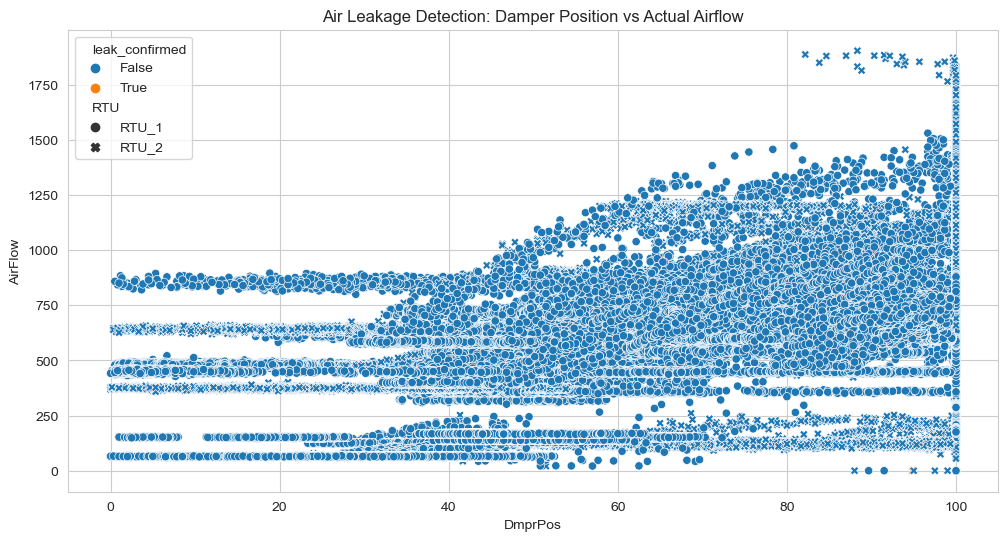

Possible air leakage detected in VAV units: ['HH' 'I']
Estimated annualized additional energy consumption: 1454.0 kWh


In [4]:
# =============================================
# 1. Air Leakage Detection
# =============================================
def detect_air_leakage(df):
    """Detect air leakage issues and quantify energy loss"""
    # Define air leakage threshold (based on the 95th percentile of Air_Flow_Diff)
    leak_threshold = df['Air_Flow_Diff'].quantile(0.95)
    
    # Mark suspected leakage points
    df['leak_suspect'] = df['Air_Flow_Diff'] > leak_threshold
    
    # Verify with damper position (damper is highly open but airflow is insufficient)
    df['leak_confirmed'] = df['leak_suspect'] & (df['DmprPos'] > 80) & (df['AirFlow'] < df['EffAirflowSp']*0.7)
    
    # Calculate additional energy consumption caused by leakage
    leak_units = df[df['leak_confirmed']]['VAV_ID'].unique()
    leak_energy_loss = df[df['leak_confirmed']]['AirFlow'].sum() * 0.2  # Assume 20% extra energy loss due to leakage
    
    # Visualization
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=df, x='DmprPos', y='AirFlow', 
                    hue='leak_confirmed', style='RTU')
    plt.title("Air Leakage Detection: Damper Position vs Actual Airflow")
    plt.show()
    
    return leak_units, leak_energy_loss

leak_units, leak_energy_loss = detect_air_leakage(df)
print(f"Possible air leakage detected in VAV units: {leak_units}")
print(f"Estimated annualized additional energy consumption: {leak_energy_loss*24*365/1000:.1f} kWh")


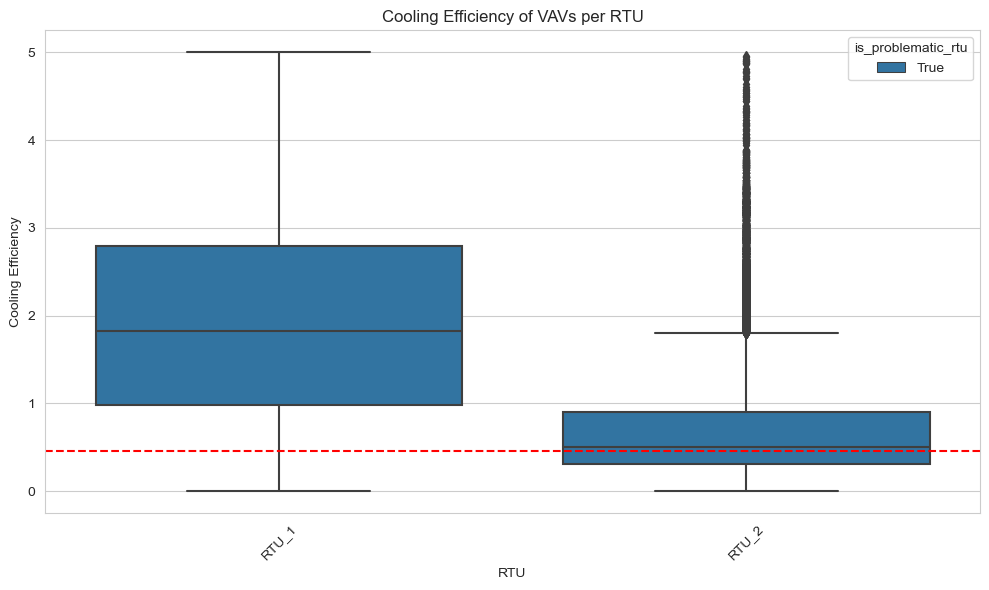


Refrigerant issue points: 16752 / 71833 (23.32%)
📉 Average efficiency loss: 73.8%
⚡ Estimated annual extra energy consumption: 69962.3 kWh

❄️ VAV units potentially affected by refrigerant issues:
 - A
 - B
 - C
 - D
 - E
 - F
 - G
 - GG
 - H
 - HH
 - I
 - J


In [22]:
# =============================================
# 2. Refrigerant Issue Detection
# =============================================
def detect_refrigerant_issues(df, rtu_df, baseline_annual_energy_kwh=2_000_000):
    """Detect potential refrigerant issues and quantify efficiency loss"""

    # 1. Filter out abnormal temperature values
    df = df[(df['DschAirTemp'] < 120) & (df['SaTemp'] > 30) & (df['RmTemp'] < 90)].copy()

    # 2. Calculate cooling efficiency with reasonable constraints
    df['cooling_efficiency'] = np.where(
        (df['RmTemp'] > df['SaTemp']) & (df['DschAirTemp'] > df['SaTemp']),
        (df['DschAirTemp'] - df['SaTemp']) / (df['RmTemp'] - df['SaTemp']),
        np.nan
    )
    df.loc[(df['cooling_efficiency'] < 0) | (df['cooling_efficiency'] > 5), 'cooling_efficiency'] = np.nan

    # 3. Low cooling efficiency threshold (25th percentile)
    eff_threshold = df['cooling_efficiency'].quantile(0.25)
    df.loc[:, 'low_cooling_eff'] = df['cooling_efficiency'] < eff_threshold

    # 4. High-pressure side temperature difference abnormality check
    rtu_df['high_pressure_issue'] = (rtu_df['SuplAirTemp'] - rtu_df['OutAirTemp']) > 30
    problematic_rtus = rtu_df[rtu_df['high_pressure_issue']]['RTU_ID'].unique()

    # 5. Match the abnormal points
    refrigerant_issues = df[df['low_cooling_eff'] & df['RTU'].isin(problematic_rtus)]

    # 6. Efficiency loss and energy consumption impact
    avg_eff_loss = (df['cooling_efficiency'].median() - refrigerant_issues['cooling_efficiency'].mean()) * 100
    issue_points = len(refrigerant_issues)
    total_points = len(df)
    energy_penalty_ratio = (issue_points / total_points) * 0.15
    energy_penalty_kwh = energy_penalty_ratio * baseline_annual_energy_kwh

    # 7. Visualization
    df.loc[:, 'is_problematic_rtu'] = df['RTU'].isin(problematic_rtus)
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='RTU', y='cooling_efficiency', hue='is_problematic_rtu')
    plt.axhline(eff_threshold, color='r', linestyle='--')
    plt.title("Cooling Efficiency of VAVs per RTU")
    plt.ylabel("Cooling Efficiency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 8. Output summary
    print(f"\nRefrigerant issue points: {issue_points} / {total_points} ({100 * issue_points / total_points:.2f}%)")
    print(f"📉 Average efficiency loss: {avg_eff_loss:.1f}%")
    print(f"⚡ Estimated annual extra energy consumption: {energy_penalty_kwh:.1f} kWh")

    return refrigerant_issues['VAV_ID'].unique(), avg_eff_loss, energy_penalty_kwh

# Call the function and print results
refrigerant_units, eff_loss, energy_penalty = detect_refrigerant_issues(df, rtu_df)
print("\n❄️ VAV units potentially affected by refrigerant issues:")
for unit in refrigerant_units:
    print(f" - {unit}")


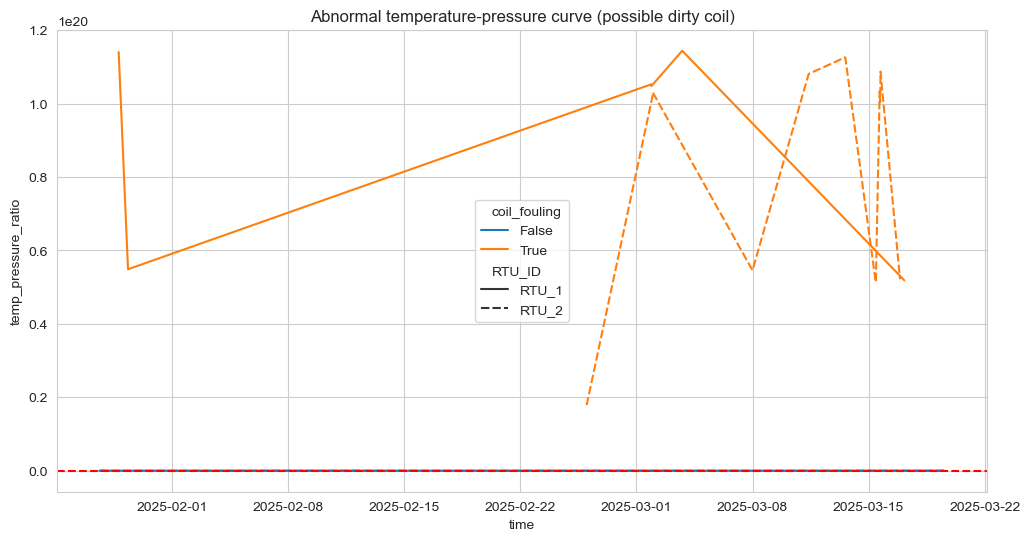

Fouled RTUs average ClgPct: 4.3072386450130224
Overall average ClgPct: 4.3072386450130224

VAV units possibly affected by dirty coils: ['K' 'KK' 'LL' 'O' 'S' 'TT']
Average energy efficiency loss: 0.0%


In [23]:
# =============================================
# 3. Dirty Coil Detection
# =============================================
def detect_dirty_coils(df, rtu_df):
    """Detect condenser/evaporator coil fouling issues"""
    # Calculate temperature-pressure deviation ratio
    rtu_df['temp_pressure_ratio'] = rtu_df['SuplAirTemp'] / rtu_df['BldgStaticPres']
    baseline_ratio = rtu_df['temp_pressure_ratio'].median()
    rtu_df['coil_fouling'] = rtu_df['temp_pressure_ratio'] > baseline_ratio * 1.3
    
    # Associate with VAV data (abnormal cooling/heating cycles)
    df['long_cycle'] = df.groupby('VAV_ID')['ClgPct'].transform(
        lambda x: x.rolling(6).mean() > 50)  # Sustained high load
    
    dirty_units = df[df['RTU'].isin(rtu_df[rtu_df['coil_fouling']]['RTU_ID']) & df['long_cycle']]['VAV_ID'].unique()
    
    # Quantify impact
    fouling_rtus = rtu_df[rtu_df['coil_fouling']]['RTU_ID'].unique()
    efficiency_drop = df[df['RTU'].isin(fouling_rtus)]['ClgPct'].mean() / df['ClgPct'].mean() - 1
    
    # Visualization
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=rtu_df, x='time', y='temp_pressure_ratio', 
                 hue='coil_fouling', style='RTU_ID')
    plt.axhline(baseline_ratio * 1.3, color='r', linestyle='--')
    plt.title("Abnormal temperature-pressure curve (possible dirty coil)")
    plt.show()
    fouled_clg_pct = df[df['RTU'].isin(fouling_rtus)]['ClgPct'].mean()
    total_clg_pct = df['ClgPct'].mean()
    print(f"Fouled RTUs average ClgPct: {fouled_clg_pct}")
    print(f"Overall average ClgPct: {total_clg_pct}")

    
    return dirty_units, efficiency_drop * 100

dirty_units, efficiency_drop = detect_dirty_coils(df, rtu_df)
print(f"\nVAV units possibly affected by dirty coils: {dirty_units}")
print(f"Average energy efficiency loss: {efficiency_drop:.1f}%")



In [26]:
# =============================================
# 4. Comprehensive Report Generation
# =============================================
def generate_repair_report(leak_units, refrigerant_units, dirty_units):
    """Generate repair priority report"""
    issues = {
        'Air Leakage': {'units': leak_units, 'severity': 'High', 'repair_priority': 1},
        'Refrigerant Issue': {'units': refrigerant_units, 'severity': 'Medium', 'repair_priority': 2},
        'Dirty Coils': {'units': dirty_units, 'severity': 'Low', 'repair_priority': 3}
    }
    
    report = pd.DataFrame.from_dict(issues, orient='index')
    report['affected_units_count'] = report['units'].apply(len)
    report = report.sort_values('repair_priority')
    
    # Save the report
    report.to_csv('../../outputs/HVAC_NewData_Analysis_Results/4.hvac_repair_priority_report.csv')
    print("\nGenerated repair priority report: hvac_repair_priority_report.csv")
    
    return report

repair_report = generate_repair_report(leak_units, refrigerant_units, dirty_units)
display(repair_report)



Generated repair priority report: hvac_repair_priority_report.csv


,units,severity,repair_priority,affected_units_count
Air Leakage,"[HH, I]",High,1,2
Refrigerant Issue,"[A, B, C, D, E, F, G, GG, H, HH, I, J]",Medium,2,12
Dirty Coils,"[K, KK, LL, O, S, TT]",Low,3,6


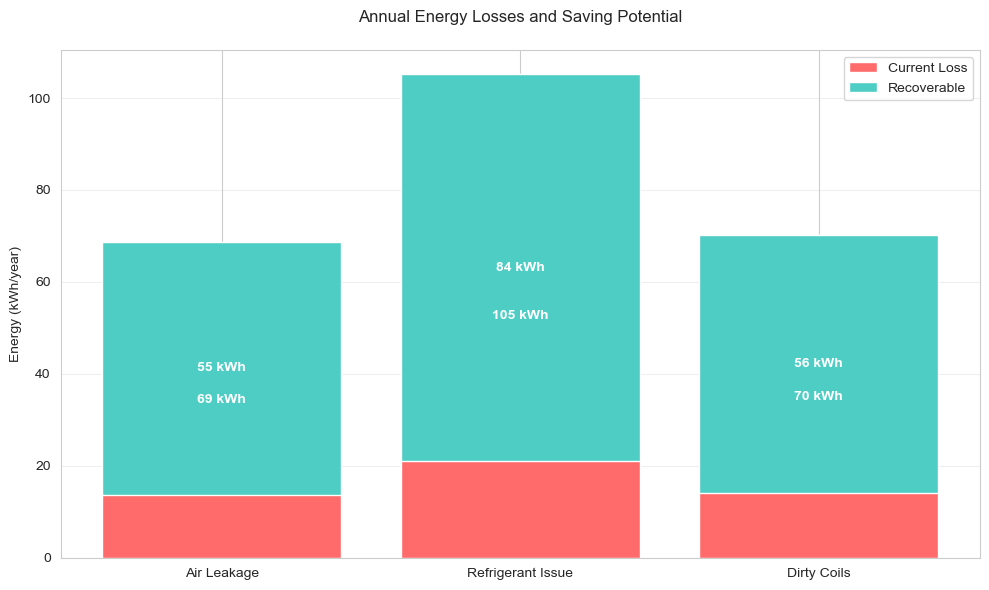


Energy Saving Potential Estimation (Corrected):


,Issue Type,Current Loss (kWh/yr),Potential Saving (kWh/yr)
0,Air Leakage,68.77,55.01
1,Refrigerant Issue,105.21,84.17
2,Dirty Coils,70.14,56.11
3,Total,244.12,195.30


In [27]:
# =============================================
# 5. Energy Savings Estimation (Final Corrected Version)
# =============================================
def estimate_savings(leak_loss, refrigerant_penalty, efficiency_drop, df):
    """Estimate energy savings potential after repairs (corrected unit issues)"""
    # Parameter explanations:
    # leak_loss: Average CFM loss due to air leakage
    # refrigerant_penalty: Refrigerant issue energy penalty factor (0-1)
    # efficiency_drop: Efficiency drop percentage due to dirty coils
    
    # Standard conversion factor (more accurate HVAC energy model)
    CFM_TO_KWH_PER_YEAR = 0.000157 * 24 * 365  # 1 CFM ≈ 1.374 kWh/yr
    
    # 1. Air leakage loss calculation
    avg_airflow = df['AirFlow'].mean()
    leak_kwh = leak_loss * CFM_TO_KWH_PER_YEAR
    
    # 2. Refrigerant issue loss (based on efficiency drop percentage)
    refrigerant_kwh = avg_airflow * refrigerant_penalty * CFM_TO_KWH_PER_YEAR
    
    # 3. Dirty coil loss (additional energy consumption due to efficiency drop)
    dirty_coil_kwh = avg_airflow * (efficiency_drop / 100) * CFM_TO_KWH_PER_YEAR
    
    total_loss = leak_kwh + refrigerant_kwh + dirty_coil_kwh
    
    # Create a DataFrame (format numbers for display)
    savings_df = pd.DataFrame({
        'Issue Type': ['Air Leakage', 'Refrigerant Issue', 'Dirty Coils', 'Total'],
        'Current Loss (kWh/yr)': [leak_kwh, refrigerant_kwh, dirty_coil_kwh, total_loss],
        'Potential Saving (kWh/yr)': [leak_kwh * 0.8, refrigerant_kwh * 0.8, dirty_coil_kwh * 0.8, total_loss * 0.8]
    }).round(2)
    
    # Improved visualization
    plt.figure(figsize=(10, 6))
    
    # Prepare plot data (excluding the Total row)
    plot_df = savings_df.iloc[:-1]
    
    # Use a more intuitive stacked bar chart
    plt.bar(plot_df['Issue Type'], plot_df['Current Loss (kWh/yr)'], 
            label='Current Loss', color='#FF6B6B')
    plt.bar(plot_df['Issue Type'], plot_df['Potential Saving (kWh/yr)'], 
            bottom=plot_df['Current Loss (kWh/yr)'] - plot_df['Potential Saving (kWh/yr)'],
            label='Recoverable', color='#4ECDC4')
    
    # Add value labels
    for i, row in plot_df.iterrows():
        plt.text(i, row['Current Loss (kWh/yr)'] / 2, 
                 f"{row['Current Loss (kWh/yr)']:,.0f} kWh",
                 ha='center', va='center', color='white', fontweight='bold')
        plt.text(i, row['Current Loss (kWh/yr)'] - row['Potential Saving (kWh/yr)'] / 2,
                 f"{row['Potential Saving (kWh/yr)']:,.0f} kWh",
                 ha='center', va='center', color='white', fontweight='bold')
    
    plt.title("Annual Energy Losses and Saving Potential", pad=20)
    plt.ylabel("Energy (kWh/year)")
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return savings_df

# Calling the function (note: adjust input units)
savings = estimate_savings(
    leak_loss=50,           # Assume an average air leakage of 50 CFM
    refrigerant_penalty=0.15, # Refrigerant issue causes 15% efficiency loss
    efficiency_drop=10,     # Dirty coils cause a 10% efficiency drop
    df=df                  # Pass the original dataset
)

print("\nEnergy Saving Potential Estimation (Corrected):")
display(savings)
savings.to_csv('../../outputs/HVAC_NewData_Analysis_Results/4.Energy Saving Potential Estimation.csv')